# Results Tables & Figures (Explainability / Error Analysis / Cross-Attention)

This notebook **does not re-train models**. It reads artifacts produced by:

| Source notebook | Key outputs used here |
|-----------------|------------------------|
| `10_error_analysis.ipynb` | Class-pair confusion, Grad-CAM case index |
| `10_explainability.ipynb` | Modality ablation, per-class attention, sample attention summaries |
| `8_cross-attention.ipynb` | 30-seed robustness metrics for the proposed model |

Generated tables and figures are saved under **`results/tables/`**.

---

## Contents
1. **Top confused class pairs** (proposed cross-attention model)
2. **Grad-CAM** examples — correct vs incorrect predictions
3. **Per-class modality contribution** — whether image or text drives confidence more
4. **Cross-attention case studies** — 3 correct + 3 incorrect samples with image, caption, and attention plots

---
## Output summary

| File | Description |
|------|-------------|
| `results/tables/01_top_confused_pairs_cross_attention.csv` | Top confused pairs for cross-attention |
| `results/tables/01b_top_pair_per_model.csv` | Strongest confusion pair per model |
| `results/tables/02_gradcam_selected_cases.csv` | Grad-CAM cases shown in section 2 |
| `results/tables/03_per_class_modality_contribution.csv` | Per-class image vs text influence |
| `results/tables/03_per_class_modality_contribution.png` | Bar chart of modality drops |
| `results/tables/04_cross_attention_case_studies.csv` | Selected correct/incorrect attention examples |

Re-run `10_error_analysis.ipynb` / `10_explainability.ipynb` if PNG artifacts under `results/explainability/` are missing.

## Setup — paths and helpers

In [1]:
from __future__ import annotations

import os
import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as IPyImage, Markdown, display
from PIL import Image
from sklearn.model_selection import train_test_split

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

RANDOM_STATE = 42
TOP_K_PAIRS = 15
N_GRADCAM_EACH = 3
N_CROSS_ATTN_EACH = 3
EXAMPLE_SEED = 13  # seed used for cross-attention case-study panels
VAL_RATIO, TEST_RATIO = 0.15, 0.15
NUM_SEEDS_TO_USE = 10


def resolve_paths() -> Tuple[Path, Path, Path]:
    cwd = Path.cwd().resolve()
    for root in [cwd, cwd / "FusionStyle", cwd.parent / "FusionStyle"]:
        data_dir = root / "FashionStyle14_v1"
        if (data_dir / "complete_dataset.csv").is_file():
            return root, data_dir, data_dir / "caption" / "fashion_captions_llava_success.csv"
    raise FileNotFoundError("FashionStyle14_v1 not found. Run this notebook from FusionStyle/.")


def load_seeds(seeds_file: Path) -> List[int]:
    content = seeds_file.read_text(encoding="utf-8")
    matches = re.findall(r"Seed\s+(\d+)", content, flags=re.IGNORECASE)
    return sorted({int(s) for s in matches})[:NUM_SEEDS_TO_USE]


def normalize_rel_path(path_str: str) -> str:
    return str(path_str).strip().replace("\\", "/")


def canonical_merge_key(raw: str, image_root: Path) -> str:
    s = normalize_rel_path(raw).lstrip("./")
    low = s.lower()
    if low.startswith("fashionstyle14_v1/"):
        s = s[len("fashionstyle14_v1/") :].lstrip("/")
        low = s.lower()
    marker = "dataset/"
    ix = low.find(marker)
    if ix >= 0:
        return normalize_rel_path(s[ix:])
    p = Path(s)
    if p.is_absolute():
        try:
            rel = Path(p.resolve()).relative_to(image_root.resolve())
            return normalize_rel_path(str(rel).replace(os.sep, "/"))
        except ValueError:
            pass
    return s


def load_image_only_frame(csv_path: Path, image_root: Path) -> pd.DataFrame:
    lines = csv_path.read_text(encoding="utf-8").splitlines()
    rel = [ln.strip() for ln in lines if ln.strip()]
    df = pd.DataFrame({"rel_path": rel})
    df["rel_path"] = df["rel_path"].map(normalize_rel_path)
    df["merge_key"] = df["rel_path"].map(lambda r: canonical_merge_key(r, image_root))
    df["style"] = df["merge_key"].str.split("/").str[1]
    df["abs_path"] = df["rel_path"].apply(lambda r: str((image_root / r.replace("/", os.sep)).resolve()))
    return df[df["abs_path"].map(os.path.isfile)].reset_index(drop=True)


def load_captions(path: Path, image_root: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8")
    if "status" in df.columns:
        df = df[df["status"].astype(str).str.lower() == "success"]
    path_col = next(c for c in df.columns if c.lower().strip() in {"image_path", "rel_path", "path", "filename"})
    cap_col = next(c for c in df.columns if "caption" in c.lower() or c.lower() in {"text", "description"})
    out = df[[path_col, cap_col]].rename(columns={path_col: "raw_image_path", cap_col: "caption"})
    out["merge_key"] = out["raw_image_path"].map(lambda r: canonical_merge_key(r, image_root))
    out["caption"] = out["caption"].fillna("").astype(str).str.strip()
    return out[out["caption"] != ""].drop_duplicates("merge_key", keep="last")


def split_by_seed(df: pd.DataFrame, seed_value: int):
    train_df, temp_df = train_test_split(
        df, test_size=VAL_RATIO + TEST_RATIO, stratify=df["style"], random_state=seed_value
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        stratify=temp_df["style"],
        random_state=seed_value,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


PROJECT_ROOT, DATA_DIR, CAPTION_CSV = resolve_paths()
IMAGE_ROOT = DATA_DIR
COMPLETE_CSV = DATA_DIR / "complete_dataset.csv"
SEEDS = load_seeds(DATA_DIR / "seeds_list.txt")

df_images = load_image_only_frame(COMPLETE_CSV, IMAGE_ROOT)
cap_df = load_captions(CAPTION_CSV, IMAGE_ROOT)
df_mm = df_images.merge(cap_df[["merge_key", "caption"]], on="merge_key", how="inner").reset_index(drop=True)

classes = sorted(df_images["style"].unique().tolist())
style_to_idx = {s: i for i, s in enumerate(classes)}
idx_to_style = {i: s for s, i in style_to_idx.items()}

EXPLAIN_ROOT = PROJECT_ROOT / "results" / "explainability"
PROPOSED_ROOT = PROJECT_ROOT / "results" / "proposed" / "cross_attention"
TABLE_OUT = PROJECT_ROOT / "results" / "tables"
TABLE_OUT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("EXPLAIN_ROOT:", EXPLAIN_ROOT)
print("TABLE_OUT:", TABLE_OUT)
print("Classes:", classes)
print("Seeds:", SEEDS)

PROJECT_ROOT: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle
EXPLAIN_ROOT: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\explainability
TABLE_OUT: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\tables
Classes: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Seeds: [13, 14, 16, 17, 45, 48, 53, 58, 72, 102]


---
## 1. Top confused class pairs

We report the **most frequent off-diagonal mistakes** for the proposed **cross-attention** model, aggregated over all 10 robustness seeds (`10_error_analysis.ipynb` → `class_pair_confusion/cross_attention/top_confused_pairs.csv`).

- **`count`**: number of test images with true class A predicted as B (summed across seeds).
- **`rate_given_true`**: fraction of class A samples misclassified as B.

A short comparison with image-only baselines is included from `class_pair_summary.csv`.

In [2]:
pairs_path = EXPLAIN_ROOT / "class_pair_confusion" / "cross_attention" / "top_confused_pairs.csv"
summary_path = EXPLAIN_ROOT / "class_pair_confusion" / "class_pair_summary.csv"

df_pairs = pd.read_csv(pairs_path).head(TOP_K_PAIRS).copy()
df_pairs["pair"] = df_pairs["true_class"] + " → " + df_pairs["pred_class"]
df_pairs["rate_given_true_pct"] = (df_pairs["rate_given_true"] * 100).round(2)

display_cols = ["pair", "true_class", "pred_class", "count", "rate_given_true_pct"]
df_pairs_display = df_pairs[display_cols].rename(
    columns={
        "rate_given_true_pct": "rate_given_true (%)",
    }
)

out_pairs = TABLE_OUT / "01_top_confused_pairs_cross_attention.csv"
df_pairs_display.to_csv(out_pairs, index=False, encoding="utf-8")

display(Markdown(f"### Cross-attention — top {len(df_pairs_display)} confused pairs"))
display(df_pairs_display.style.hide(axis="index").format({"count": "{:,.0f}"}))

if summary_path.is_file():
    df_cp_summary = pd.read_csv(summary_path)
    display(Markdown("### Top confused pair per model (cross-attention vs image-only baselines)"))
    display(df_cp_summary.style.hide(axis="index"))
    df_cp_summary.to_csv(TABLE_OUT / "01b_top_pair_per_model.csv", index=False, encoding="utf-8")

print("Saved:", out_pairs)

### Cross-attention — top 15 confused pairs

pair,true_class,pred_class,count,rate_given_true (%)
kireime-casual → conservative,kireime-casual,conservative,218,13.800000
conservative → kireime-casual,conservative,kireime-casual,155,11.250000
girlish → feminine,girlish,feminine,151,9.100000
mode → rock,mode,rock,145,9.120000
street → rock,street,rock,105,6.840000
girlish → kireime-casual,girlish,kireime-casual,103,6.200000
feminine → girlish,feminine,girlish,102,8.430000
rock → mode,rock,mode,92,7.590000
girlish → natural,girlish,natural,88,5.300000
feminine → conservative,feminine,conservative,76,6.280000


### Top confused pair per model (cross-attention vs image-only baselines)

model,top_pair,top_count
cross_attention,kireime-casual->conservative,218
clip,conservative->kireime-casual,186
convnext,kireime-casual->conservative,260
swin,conservative->kireime-casual,208
vit,kireime-casual->conservative,271


Saved: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\tables\01_top_confused_pairs_cross_attention.csv


---
## 2. Grad-CAM examples (correct vs incorrect)

Grad-CAM overlays from `10_error_analysis.ipynb` / `10_explainability.ipynb` highlight regions in the **CLIP ViT-B/32** vision encoder that support the predicted class.

- **Success** (`case_type=success`): prediction matches the ground-truth style.
- **Failure** (`case_type=failure`): prediction differs from ground truth.

We show **3 success + 3 failure** cases for the **cross-attention** model (randomly sampled, fixed seed). PNG paths come from `gradcam/all_seeds_gradcam_cases.csv`.

> If PNG files are missing locally, re-run the Grad-CAM section in `10_error_analysis.ipynb` to regenerate them under `results/explainability/gradcam/`.

### Selected Grad-CAM cases (cross-attention)

case_type,seed,true,pred,file
success,53,rock,rock,cross_attention\seed_53\success_03.png
success,13,conservative,conservative,cross_attention\seed_13\success_05.png
success,58,ethnic,ethnic,cross_attention\seed_58\success_03.png
failure,13,natural,girlish,cross_attention\seed_13\failure_05.png
failure,53,mode,rock,cross_attention\seed_53\failure_05.png
failure,72,girlish,retro,cross_attention\seed_72\failure_01.png


#### Correct predictions (Grad-CAM)

**Success** | seed 53 | true: `rock` → pred: `rock`

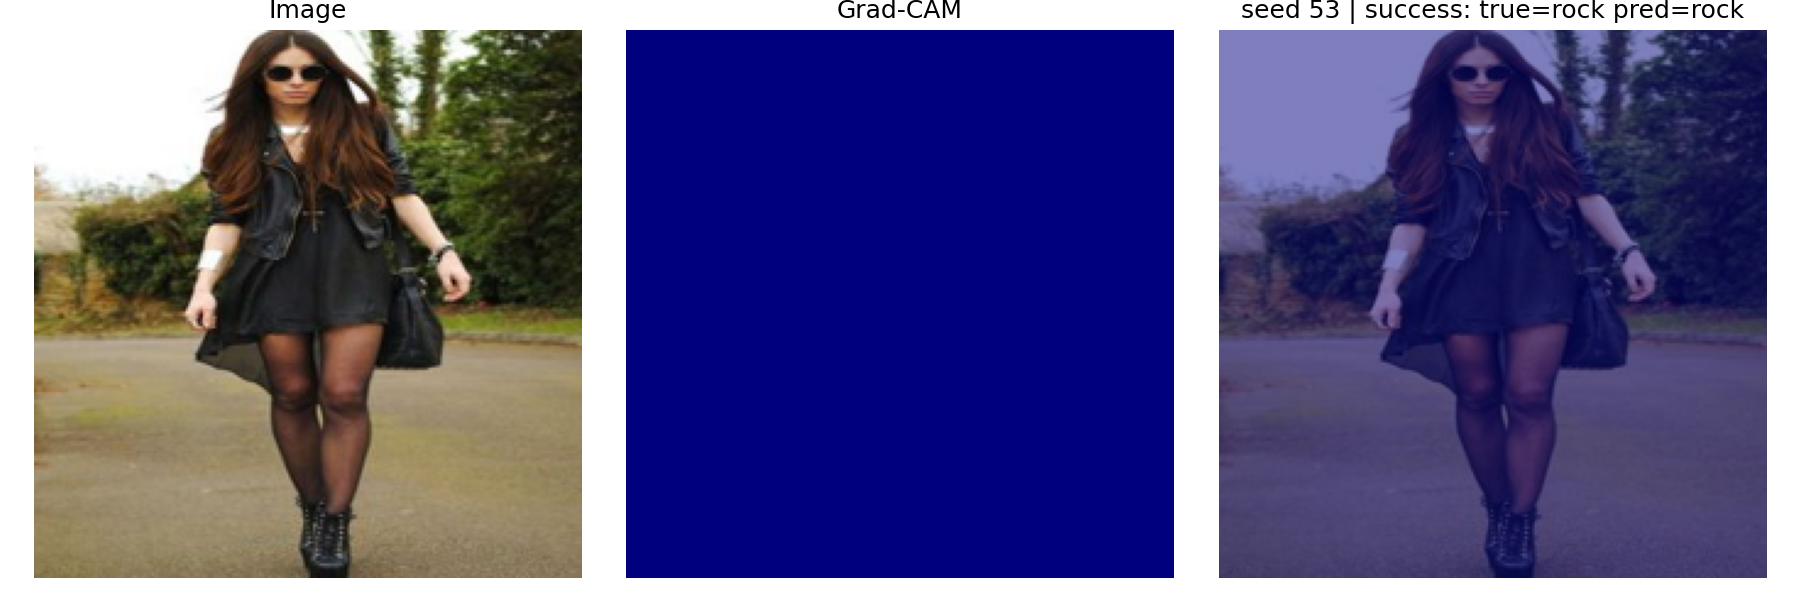

**Success** | seed 13 | true: `conservative` → pred: `conservative`

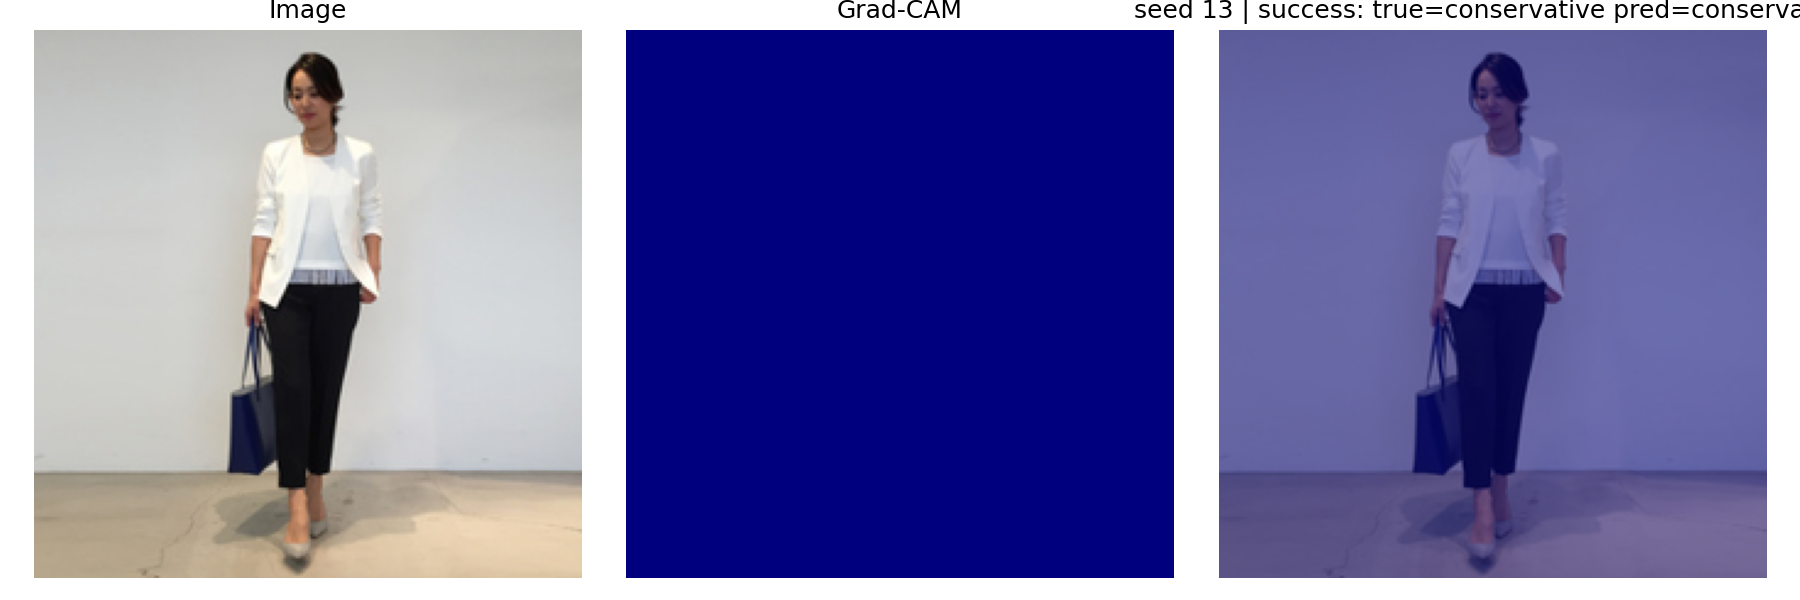

**Success** | seed 58 | true: `ethnic` → pred: `ethnic`

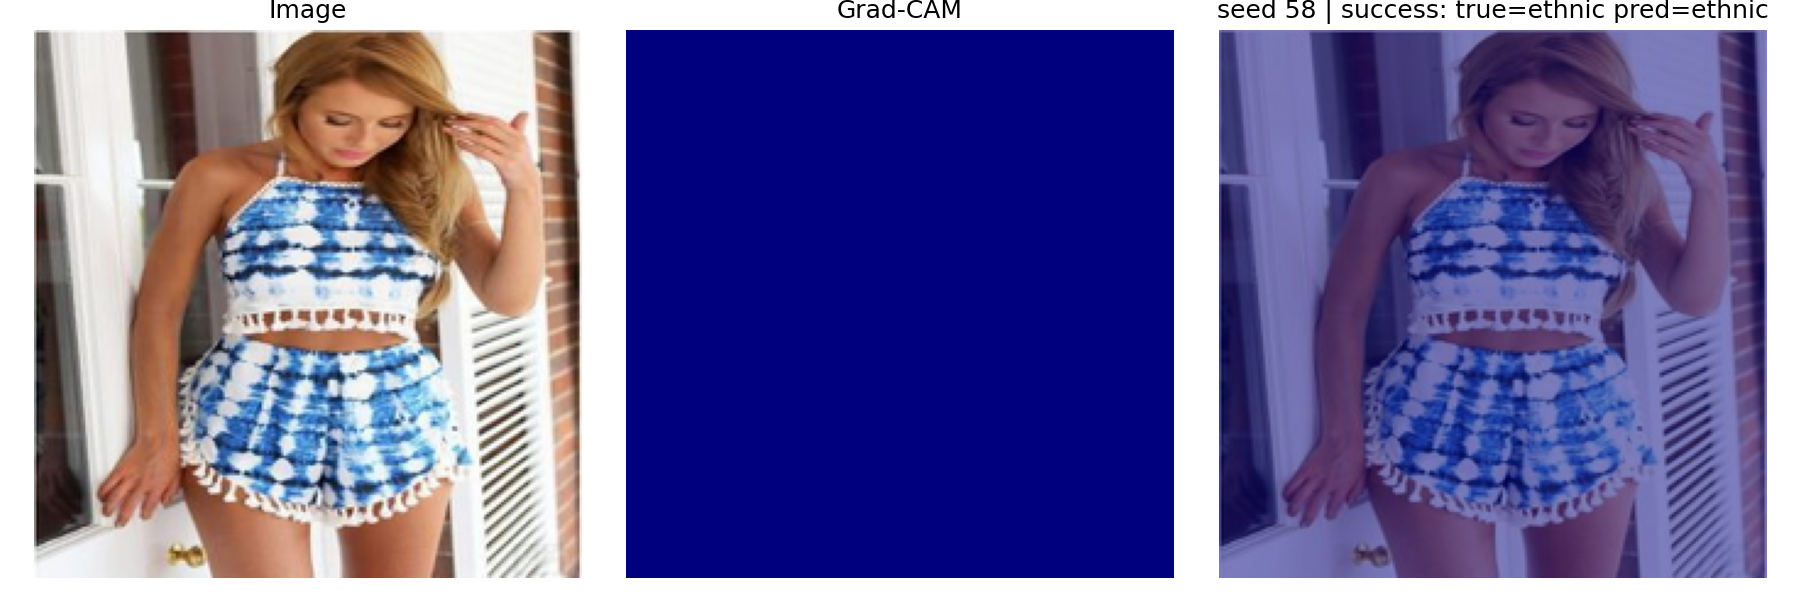

#### Incorrect predictions (Grad-CAM)

**Failure** | seed 13 | true: `natural` → pred: `girlish`

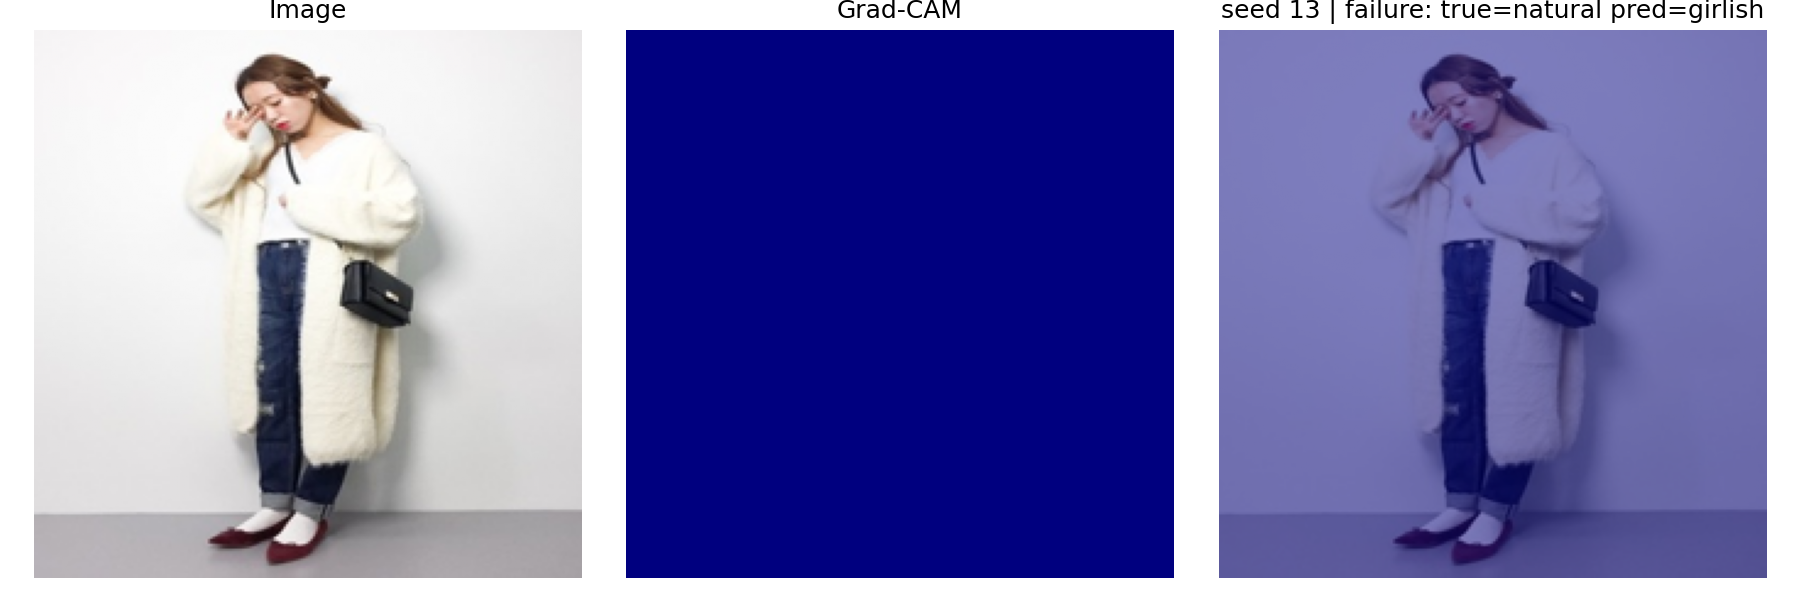

**Failure** | seed 53 | true: `mode` → pred: `rock`

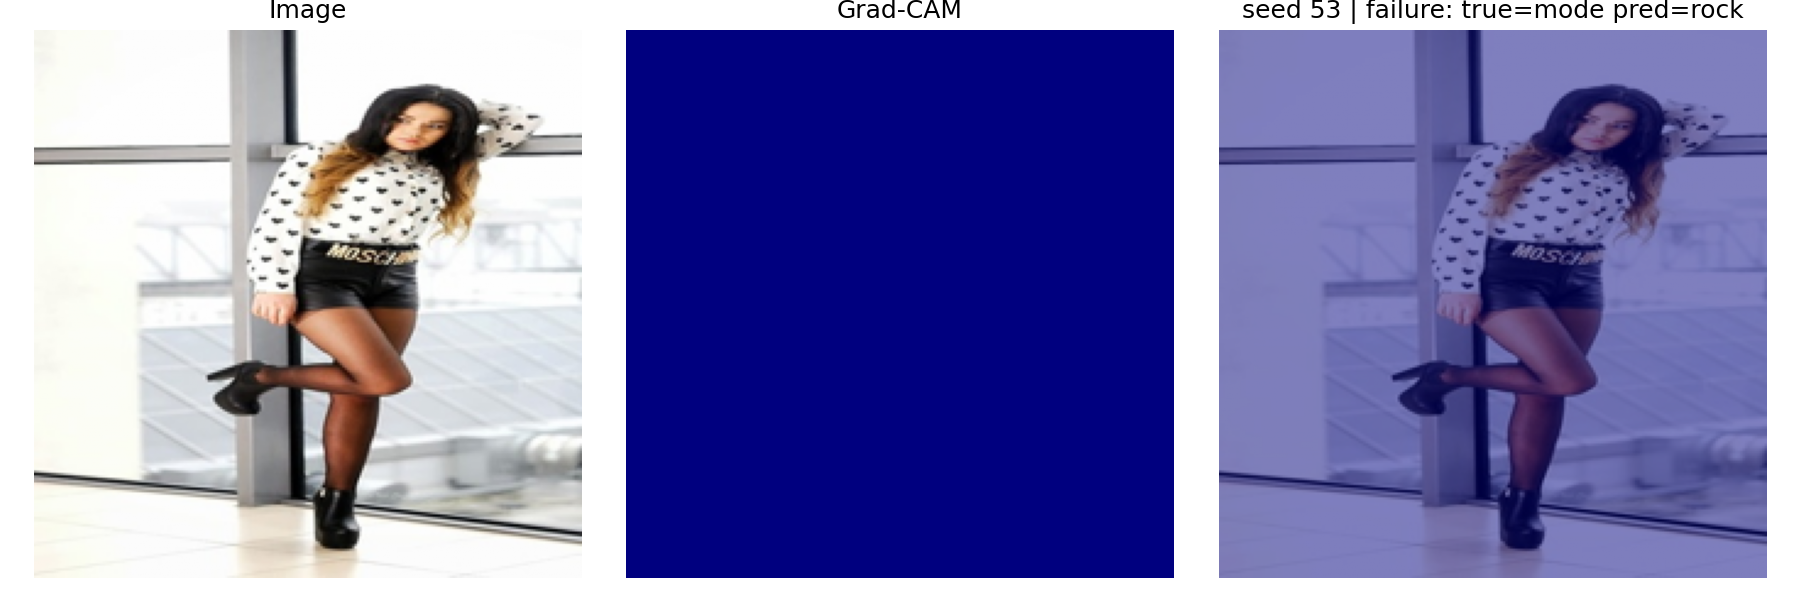

**Failure** | seed 72 | true: `girlish` → pred: `retro`

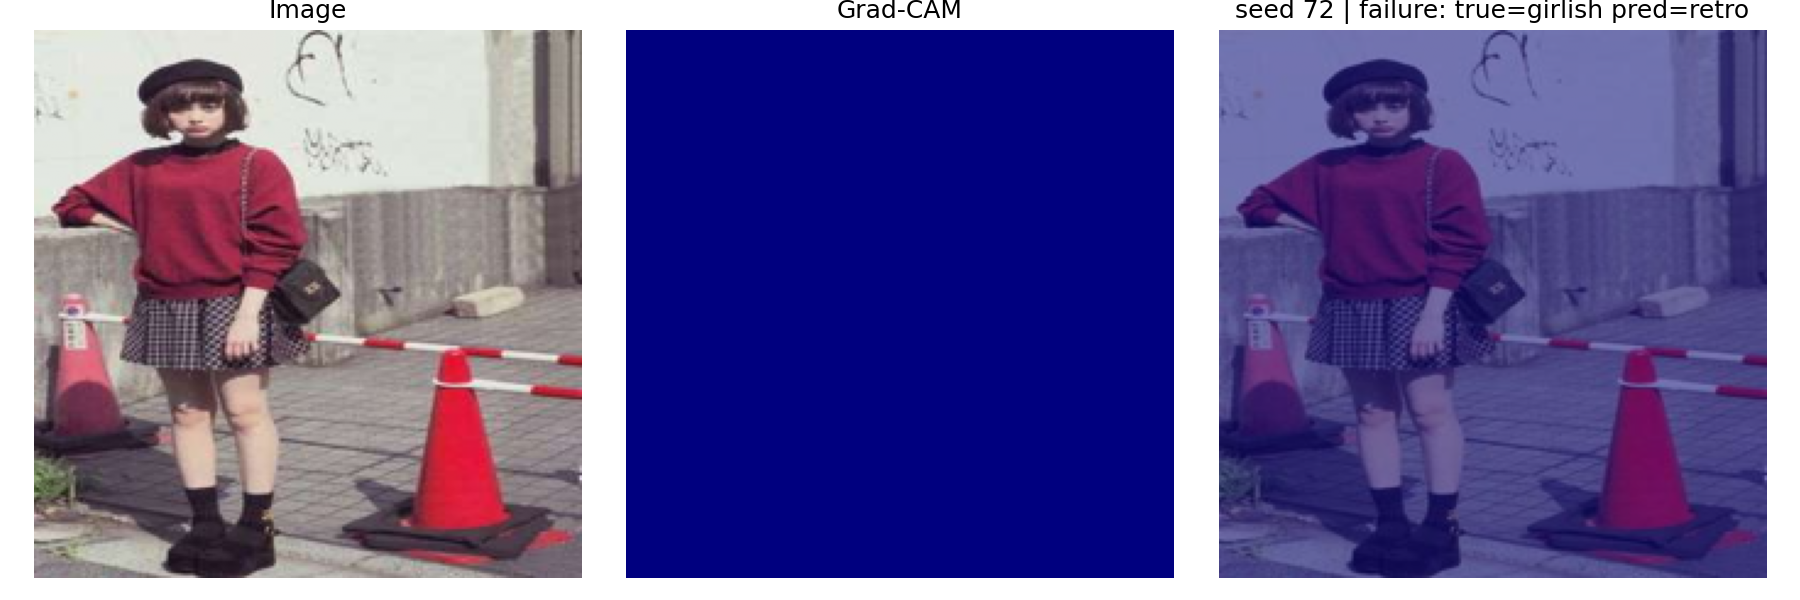

In [3]:
gradcam_index = EXPLAIN_ROOT / "gradcam" / "all_seeds_gradcam_cases.csv"
df_gradcam = pd.read_csv(gradcam_index)
df_gradcam = df_gradcam[df_gradcam["model"] == "cross_attention"].copy()

rng = np.random.default_rng(RANDOM_STATE)


def pick_gradcam_cases(case_type: str, n: int) -> pd.DataFrame:
    pool = df_gradcam[df_gradcam["case_type"] == case_type]
    if len(pool) <= n:
        return pool.copy()
    idx = rng.choice(len(pool), size=n, replace=False)
    return pool.iloc[idx].copy()


df_gradcam_success = pick_gradcam_cases("success", N_GRADCAM_EACH)
df_gradcam_failure = pick_gradcam_cases("failure", N_GRADCAM_EACH)
df_gradcam_show = pd.concat([df_gradcam_success, df_gradcam_failure], ignore_index=True)
df_gradcam_show.to_csv(TABLE_OUT / "02_gradcam_selected_cases.csv", index=False, encoding="utf-8")

display(Markdown("### Selected Grad-CAM cases (cross-attention)"))
display(df_gradcam_show[["case_type", "seed", "true", "pred", "file"]].style.hide(axis="index"))


def show_gradcam_panel(row: pd.Series) -> None:
    png_path = EXPLAIN_ROOT / "gradcam" / row["file"]
    title = (
        f"**{row['case_type'].title()}** | seed {row['seed']} | "
        f"true: `{row['true']}` → pred: `{row['pred']}`"
    )
    display(Markdown(title))
    if png_path.is_file():
        display(IPyImage(filename=str(png_path), width=420))
    else:
        display(Markdown(f"_PNG not found: `{png_path}` — regenerate via `10_error_analysis.ipynb`._"))


display(Markdown("#### Correct predictions (Grad-CAM)"))
for _, row in df_gradcam_success.iterrows():
    show_gradcam_panel(row)

display(Markdown("#### Incorrect predictions (Grad-CAM)"))
for _, row in df_gradcam_failure.iterrows():
    show_gradcam_panel(row)

---
## 3. Per-class modality contribution (image vs text)

From `10_explainability.ipynb` modality ablation (`modality_contribution/seed_*/per_sample_*.csv`):

| Setting | Meaning |
|---------|--------|
| **full** | Image + caption both available |
| **remove_text** | Image only (caption zeroed) |
| **remove_image** | Text only (image features zeroed) |

For each true style class we compute (averaged over all seeds and test samples):

- **`confidence_drop_remove_text`**: how much max-class confidence falls when text is removed → **larger drop ⇒ text contributes more**.
- **`confidence_drop_remove_image`**: drop when image is removed → **larger drop ⇒ image contributes more**.
- **`dominant_modality`**: which ablation hurts confidence more on average.
- **`modality_balance`**: `text_drop / (text_drop + image_drop)` (0.5 ≈ balanced).

Per-class **attention** peaks from `per_class_attention/all_seeds_summary.csv` are appended for interpretability (token position with highest mean cross-attention weight).

### Per-class modality contribution (cross-attention model)

true_class,dominant_modality,modality_balance_text_share,confidence_drop_remove_text,confidence_drop_remove_image,mean_conf_full,interpretation
conservative,balanced,0.484000,0.463000,0.494500,0.836000,"Removing either modality reduces confidence more (text Δ=0.463, image Δ=0.495)."
dressy,text,0.575000,0.617100,0.456800,0.990200,"Removing text reduces confidence more (text Δ=0.617, image Δ=0.457)."
ethnic,balanced,0.523000,0.544700,0.496700,0.917900,"Removing either modality reduces confidence more (text Δ=0.545, image Δ=0.497)."
fairy,text,0.555000,0.600400,0.481800,0.973700,"Removing text reduces confidence more (text Δ=0.600, image Δ=0.482)."
feminine,balanced,0.510000,0.487400,0.468900,0.860600,"Removing either modality reduces confidence more (text Δ=0.487, image Δ=0.469)."
gal,balanced,0.499000,0.537500,0.539800,0.910700,"Removing either modality reduces confidence more (text Δ=0.538, image Δ=0.540)."
girlish,balanced,0.511000,0.423300,0.405900,0.796400,"Removing either modality reduces confidence more (text Δ=0.423, image Δ=0.406)."
kireime-casual,balanced,0.483000,0.446300,0.477800,0.819400,"Removing either modality reduces confidence more (text Δ=0.446, image Δ=0.478)."
lolita,text,0.560000,0.604900,0.475100,0.978100,"Removing text reduces confidence more (text Δ=0.605, image Δ=0.475)."
mode,balanced,0.484000,0.525000,0.560200,0.898100,"Removing either modality reduces confidence more (text Δ=0.525, image Δ=0.560)."


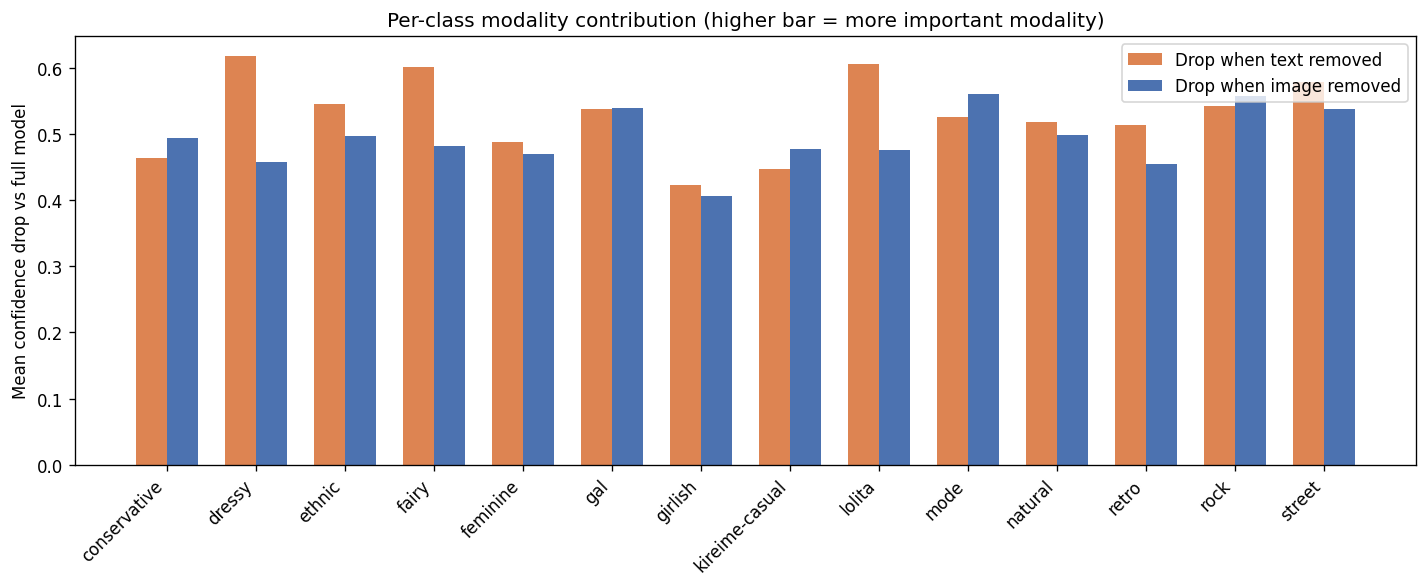

Saved: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\tables\03_per_class_modality_contribution.csv
Saved: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\tables\03_per_class_modality_contribution.png


In [4]:
per_class_rows = []

for seed in SEEDS:
    seed_dir = EXPLAIN_ROOT / "modality_contribution" / f"seed_{seed}"
    full = pd.read_csv(seed_dir / "per_sample_full.csv")
    no_text = pd.read_csv(seed_dir / "per_sample_remove_text.csv")
    no_img = pd.read_csv(seed_dir / "per_sample_remove_image.csv")

    merged = pd.DataFrame(
        {
            "seed": seed,
            "true_idx": full["true"],
            "true_class": full["true"].map(idx_to_style),
            "conf_full": full["confidence"],
            "conf_no_text": no_text["confidence"],
            "conf_no_image": no_img["confidence"],
        }
    )
    merged["drop_text"] = merged["conf_full"] - merged["conf_no_text"]
    merged["drop_image"] = merged["conf_full"] - merged["conf_no_image"]
    per_class_rows.append(merged)

df_mod_samples = pd.concat(per_class_rows, ignore_index=True)

df_modality = (
    df_mod_samples.groupby("true_class", as_index=False)
    .agg(
        n_samples=("conf_full", "count"),
        mean_conf_full=("conf_full", "mean"),
        confidence_drop_remove_text=("drop_text", "mean"),
        confidence_drop_remove_image=("drop_image", "mean"),
    )
    .sort_values("true_class")
)

total_drop = df_modality["confidence_drop_remove_text"] + df_modality["confidence_drop_remove_image"]
df_modality["modality_balance_text_share"] = (
    df_modality["confidence_drop_remove_text"] / total_drop.replace(0, np.nan)
).round(3)


def label_dominant(row) -> str:
    dt, di = row["confidence_drop_remove_text"], row["confidence_drop_remove_image"]
    if abs(dt - di) < 0.05:
        return "balanced"
    return "text" if dt > di else "image"


df_modality["dominant_modality"] = df_modality.apply(label_dominant, axis=1)
df_modality["interpretation"] = df_modality.apply(
    lambda r: (
        f"Removing {'text' if r['dominant_modality']=='text' else 'image' if r['dominant_modality']=='image' else 'either modality'} "
        f"reduces confidence more (text Δ={r['confidence_drop_remove_text']:.3f}, image Δ={r['confidence_drop_remove_image']:.3f})."
    ),
    axis=1,
)

# Optional: attach per-class attention peak token (mean over seeds)
attn_path = EXPLAIN_ROOT / "per_class_attention" / "all_seeds_summary.csv"
if attn_path.is_file():
    df_attn_cls = pd.read_csv(attn_path)
    peak_tokens = (
        df_attn_cls.groupby("class")["peak_weight"].mean().reset_index().rename(columns={"class": "true_class"})
    )
    # also mode of peak token string across seeds
    token_mode = (
        df_attn_cls.groupby("class")["peak_token_pos"]
        .agg(lambda x: int(pd.Series(x).mode().iloc[0]))
        .reset_index()
        .rename(columns={"class": "true_class", "peak_token_pos_mode": "peak_token_pos"})
    )
    df_modality = df_modality.merge(token_mode, on="true_class", how="left")
    df_modality = df_modality.merge(
        peak_tokens.rename(columns={"peak_weight": "mean_peak_attention_weight"}),
        on="true_class",
        how="left",
    )

for col in [
    "mean_conf_full",
    "confidence_drop_remove_text",
    "confidence_drop_remove_image",
]:
    df_modality[col] = df_modality[col].round(4)

out_modality = TABLE_OUT / "03_per_class_modality_contribution.csv"
df_modality.to_csv(out_modality, index=False, encoding="utf-8")

display(Markdown("### Per-class modality contribution (cross-attention model)"))
display(
    df_modality[
        [
            "true_class",
            "dominant_modality",
            "modality_balance_text_share",
            "confidence_drop_remove_text",
            "confidence_drop_remove_image",
            "mean_conf_full",
            "interpretation",
        ]
    ].style.hide(axis="index")
)

# Bar chart: text vs image confidence drop per class
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_modality))
w = 0.35
ax.bar(x - w / 2, df_modality["confidence_drop_remove_text"], width=w, label="Drop when text removed", color="#dd8452")
ax.bar(x + w / 2, df_modality["confidence_drop_remove_image"], width=w, label="Drop when image removed", color="#4c72b0")
ax.set_xticks(x)
ax.set_xticklabels(df_modality["true_class"], rotation=45, ha="right")
ax.set_ylabel("Mean confidence drop vs full model")
ax.set_title("Per-class modality contribution (higher bar = more important modality)")
ax.legend(loc="upper right")
fig.tight_layout()
fig_path = TABLE_OUT / "03_per_class_modality_contribution.png"
fig.savefig(fig_path, dpi=150)
plt.show()
plt.close(fig)

print("Saved:", out_modality)
print("Saved:", fig_path)

---
## 4. Cross-attention case studies (correct vs incorrect)

We sample **3 correct** and **3 incorrect** test examples from the attention summary (`attention_weights/all_seeds_sample_attention_summary.csv`), then show:

1. Input **image**
2. LLaVA **caption**
3. Saved **text-token attention** and **image-query heatmap** plots (when available)

Model checkpoints and 30-seed metrics come from `8_cross-attention.ipynb` → `results/proposed/cross_attention/`.

### Proposed cross-attention — 10-seed test metrics (`8_cross-attention.ipynb`)

metric,mean,std,min,max,median,ci_95_lower,ci_95_upper,n,model
accuracy,0.836831,0.009734,0.818870,0.853179,0.836781,0.829491,0.844172,10,cross_attention
macro_precision,0.839481,0.009424,0.825533,0.857721,0.838418,0.832374,0.846587,10,cross_attention
macro_recall,0.838919,0.009767,0.820276,0.854076,0.837561,0.831555,0.846284,10,cross_attention
macro_f1,0.837017,0.009630,0.819736,0.854265,0.836520,0.829755,0.844278,10,cross_attention


## Case studies for seed **13** (3 correct + 3 incorrect)

### Correct predictions

### ✅ Correct | sample `07` | seed 13

- **True style:** `natural`
- **Predicted:** `natural`
- **Confidence:** 0.997
- **Peak attended token:** `the`


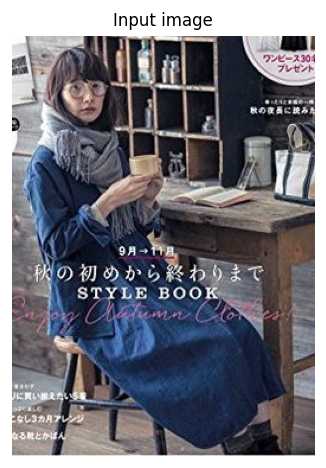

**Caption:** The image features a woman wearing a blue dress sitting at a wooden dining table. She is holding a cup, possibly a coffee or tea, in her hand. Two books rest on the table along with a bottle, possibly containing a beverage or condiment. 

There are three chairs around the table, one on the left, the right, and at the back. The dining table is positioned in the middle of the scene. The woman is wearing a scarf, which adds to the overall stylish appearance. The presence of books and a cup suggests…

**Cross-attention over text tokens (bar)**

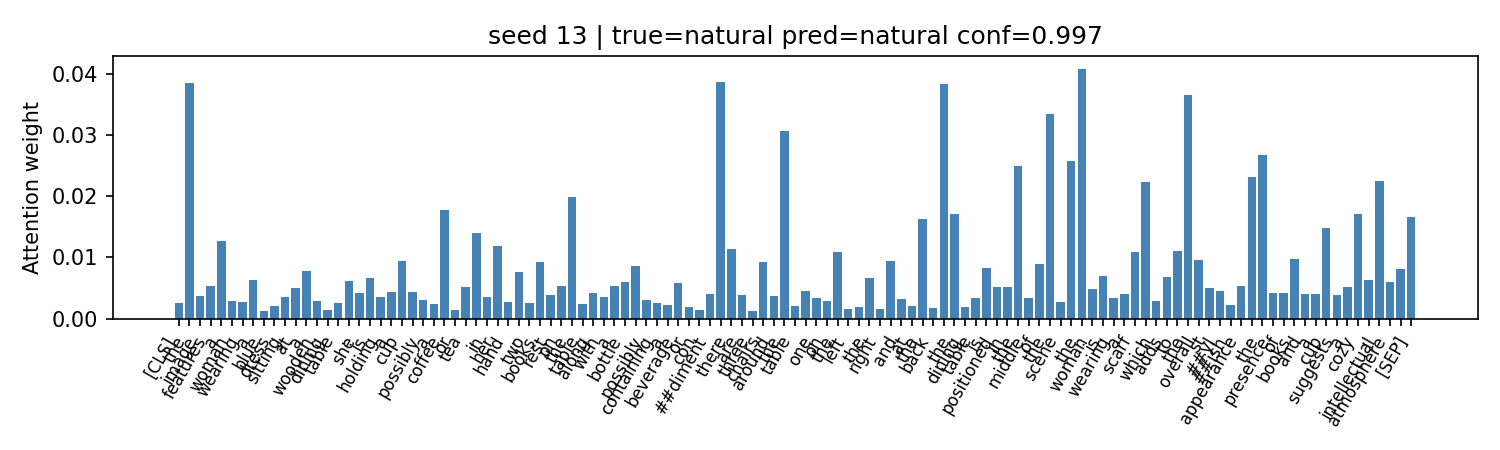

**Image-query attention heatmap**

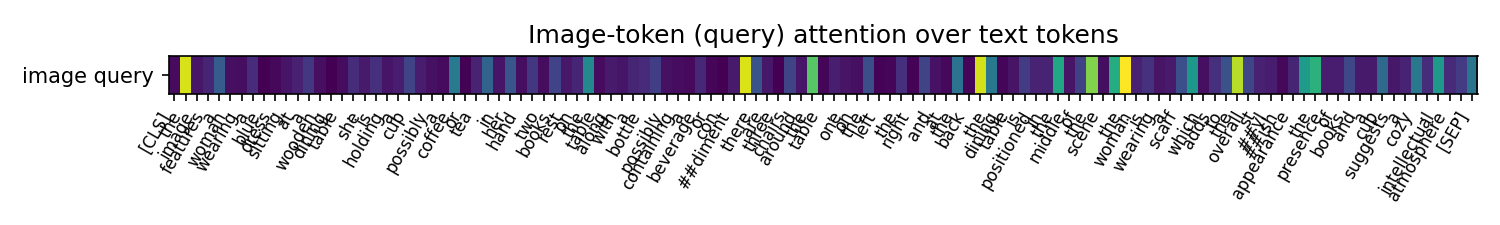

---

### ✅ Correct | sample `02` | seed 13

- **True style:** `mode`
- **Predicted:** `mode`
- **Confidence:** 0.671
- **Peak attended token:** `hips`


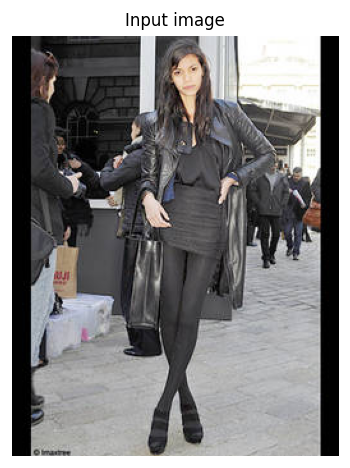

**Caption:** In this image, a woman stands out in the crowd as she poses for a picture on a sidewalk. She is wearing a black outfit that consists of tight black pants and a black jacket with a leather jacket. The woman has a confident, stylish, and edgy look, giving the impression of a hipster vibe. 

There are multiple people in the image, forming a diverse group. Some of them have handbags, indicating that they might be out for shopping, going to a business meeting, or running errands. The presence of hand…

**Cross-attention over text tokens (bar)**

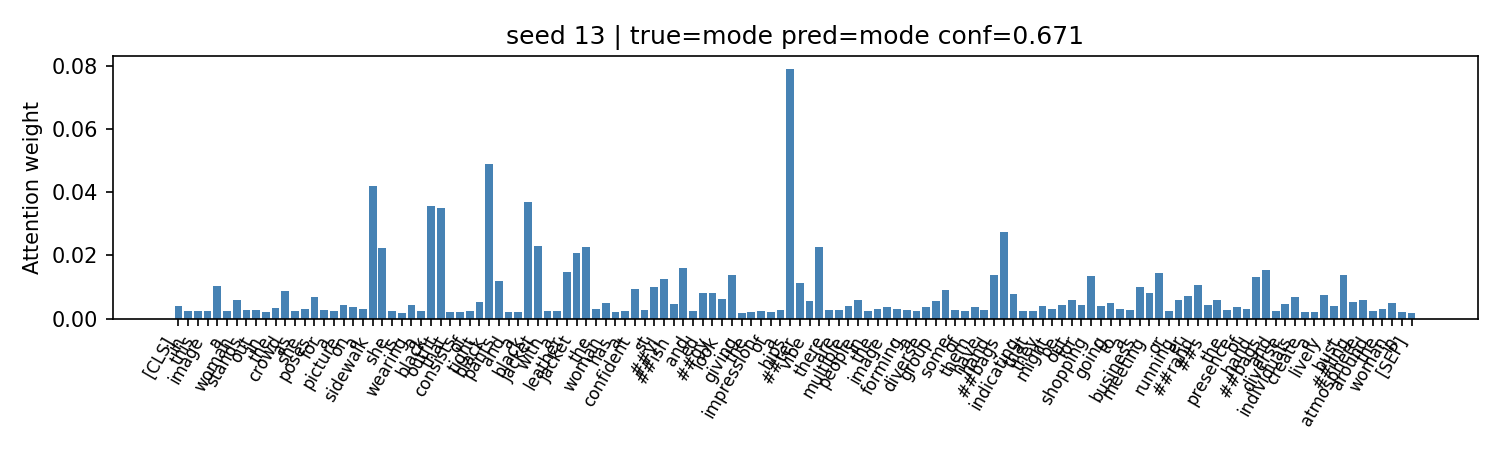

**Image-query attention heatmap**

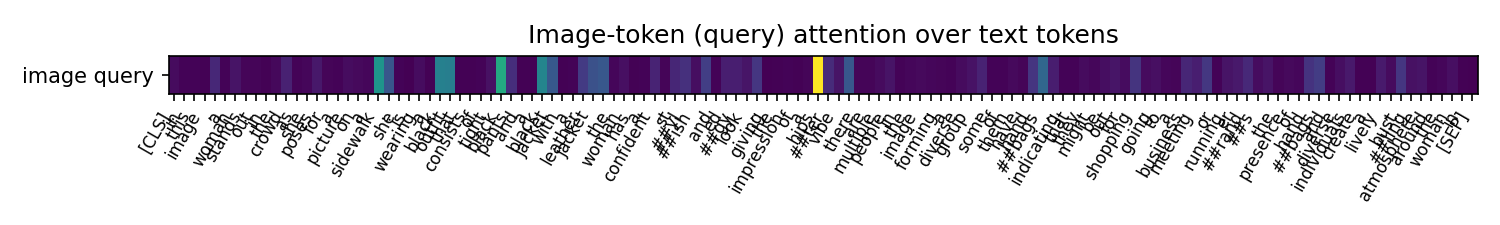

---

### ✅ Correct | sample `05` | seed 13

- **True style:** `ethnic`
- **Predicted:** `ethnic`
- **Confidence:** 0.997
- **Peak attended token:** `the`


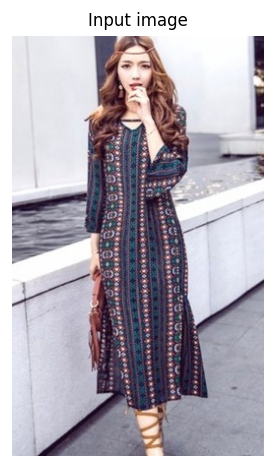

**Caption:** The image features a woman wearing a green dress, which has a colorful and patterned design. She stands next to a water feature, possibly a fountain, with her hands on her hips. The scene appears to be set outdoors.

In terms of fashion, the woman's attire seems to be inspired by a modern and ethnic style. The color combination of green and other hues, along with the patterned design of her dress, contributes to a vibrant and fashionable aesthetic. The fact that the woman is posing for the camer…

**Cross-attention over text tokens (bar)**

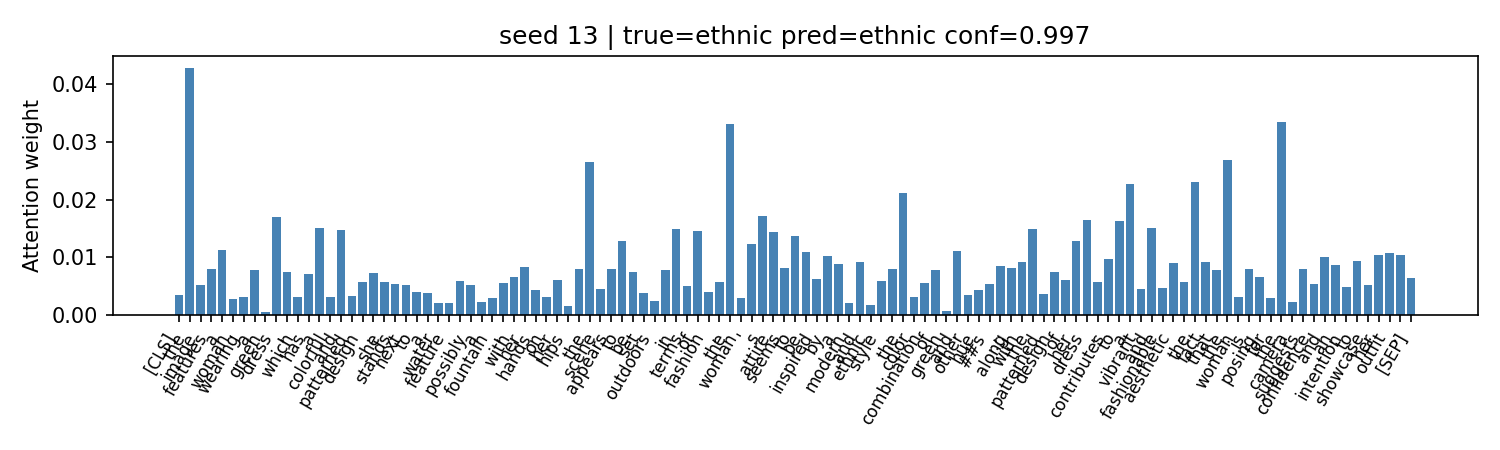

**Image-query attention heatmap**

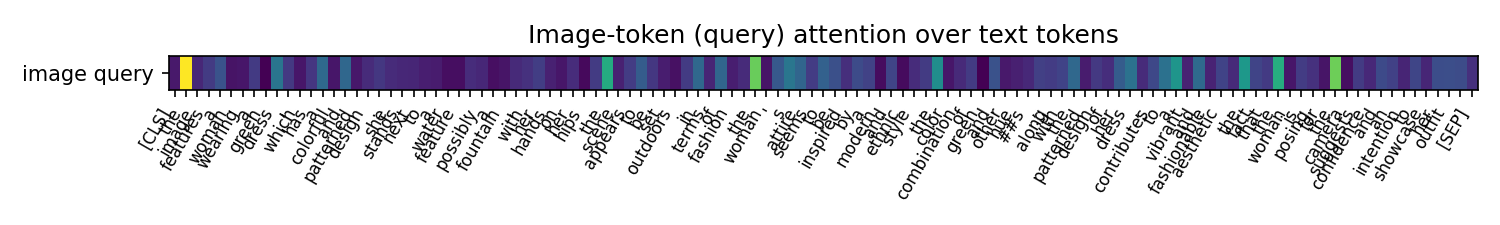

---

### Incorrect predictions

### ❌ Incorrect | sample `00` | seed 13

- **True style:** `retro`
- **Predicted:** `feminine`
- **Confidence:** 0.961
- **Peak attended token:** `dress`


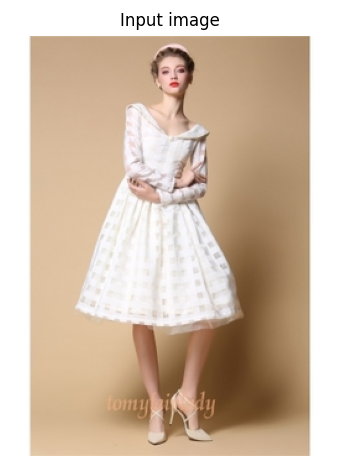

**Caption:** The image features a woman in a white dress standing on a white carpet. The dress has a beautiful lace design and appears to be a floral print, giving it a vintage and elegant look. The woman is wearing shoes, which complete the overall stylish appearance. The white color of the dress and carpet adds a touch of sophistication to the outfit, creating a timeless and chic look. The style is likely to be categorized as vintage, as the lace and floral print elements evoke a sense of past eras.

**Cross-attention over text tokens (bar)**

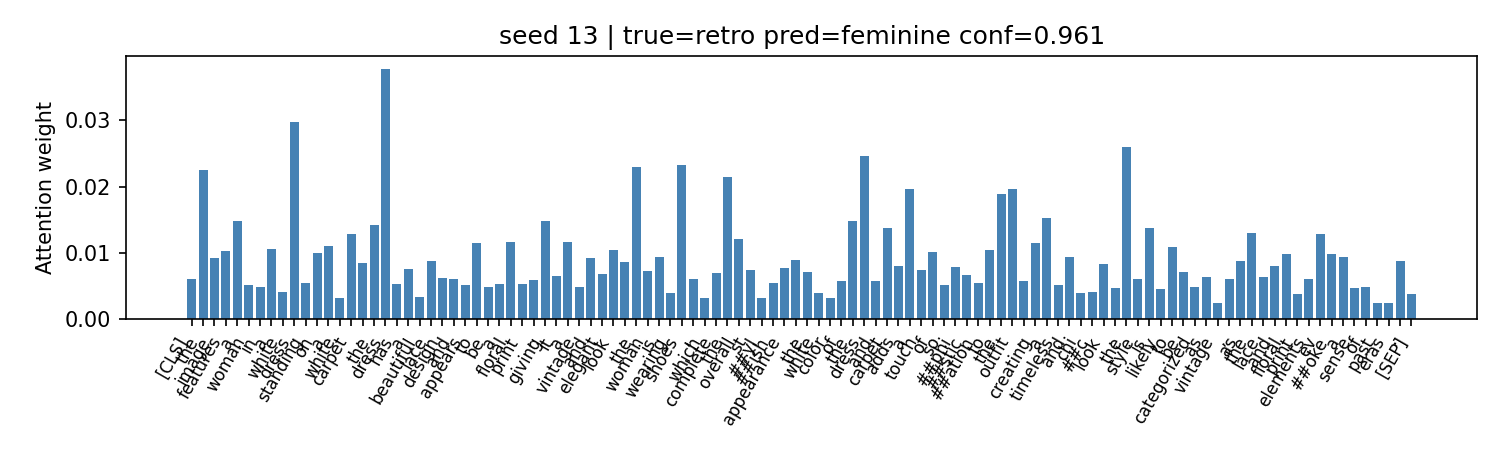

**Image-query attention heatmap**

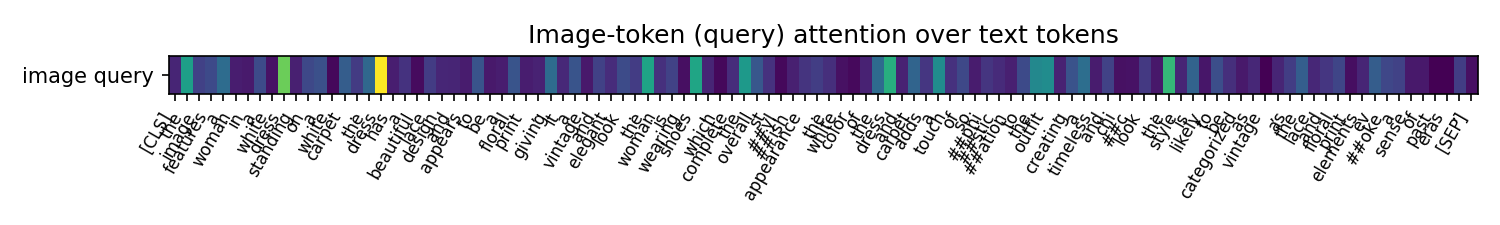

---

### ❌ Incorrect | sample `04` | seed 13

- **True style:** `retro`
- **Predicted:** `fairy`
- **Confidence:** 0.991
- **Peak attended token:** `.`


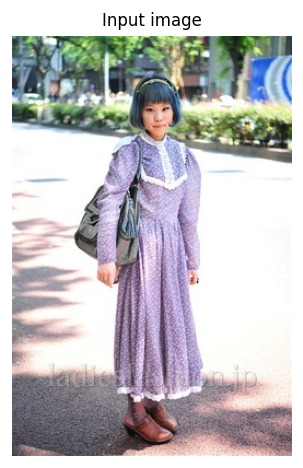

**Caption:** In the image, a young lady wearing a purple dress with a matching headband and jacket is standing on a street. The dress appears to be a floor length with a shirt underneath and a floral pattern. The woman's outfit is neat and sophisticated.

She is also carrying a handbag, which is brown in color and placed close to her body. The overall aesthetic of the image gives an impression of a stylish and fashionable young woman, possibly in her teens. The street setting adds a touch of casualness to th…

**Cross-attention over text tokens (bar)**

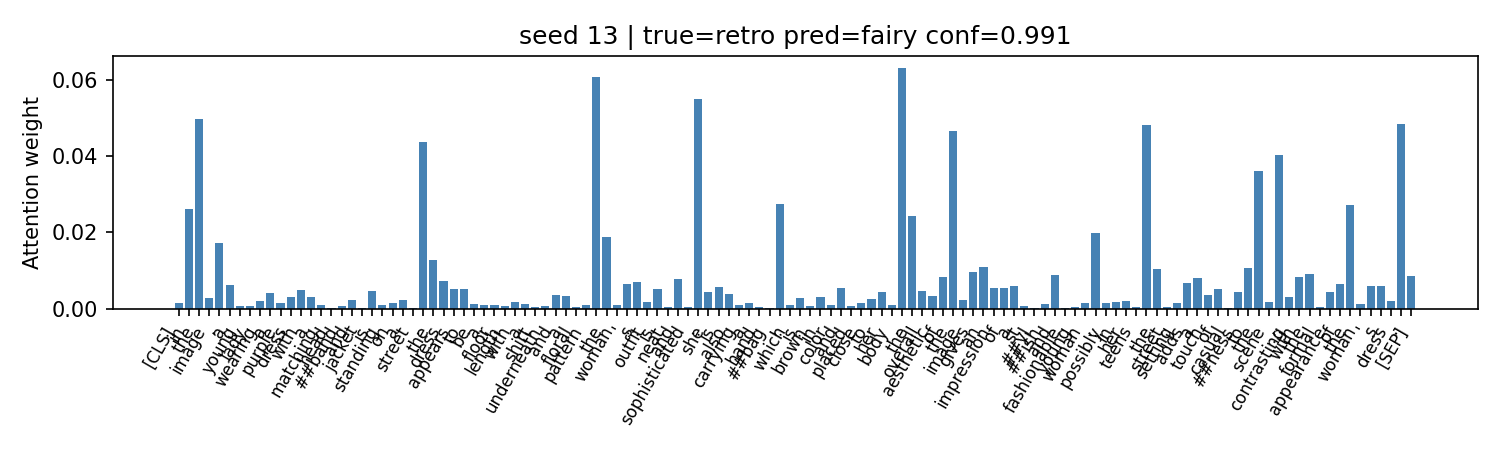

**Image-query attention heatmap**

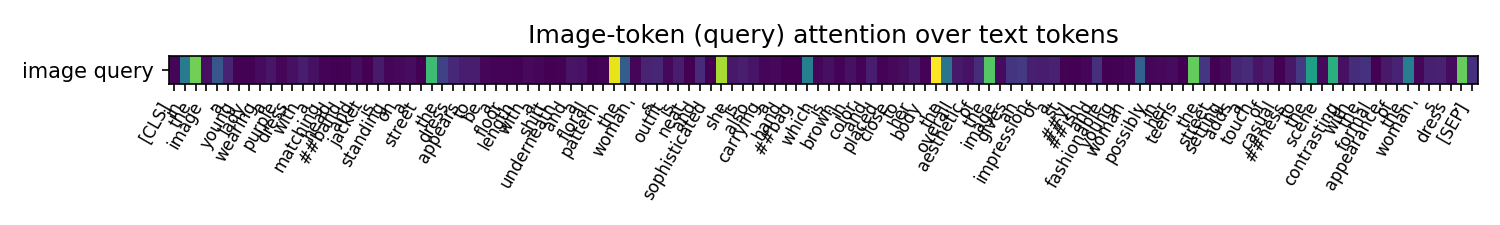

---

### ❌ Incorrect | sample `01` | seed 13

- **True style:** `retro`
- **Predicted:** `girlish`
- **Confidence:** 0.885
- **Peak attended token:** `.`


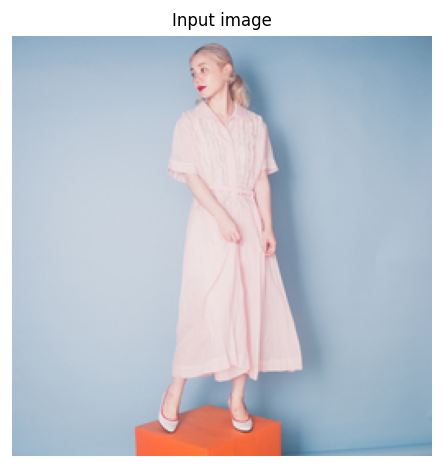

**Caption:** The image features a woman dressed in a feminine style, wearing a pink dress that has a lace pattern on the top. She is accessorized with pink shoes and stands on a platform, possibly on a pedestal. The overall aesthetic suggests a classic, elegant, and fashionable style. The woman's attire and pose create a sense of sophistication and poise.

**Cross-attention over text tokens (bar)**

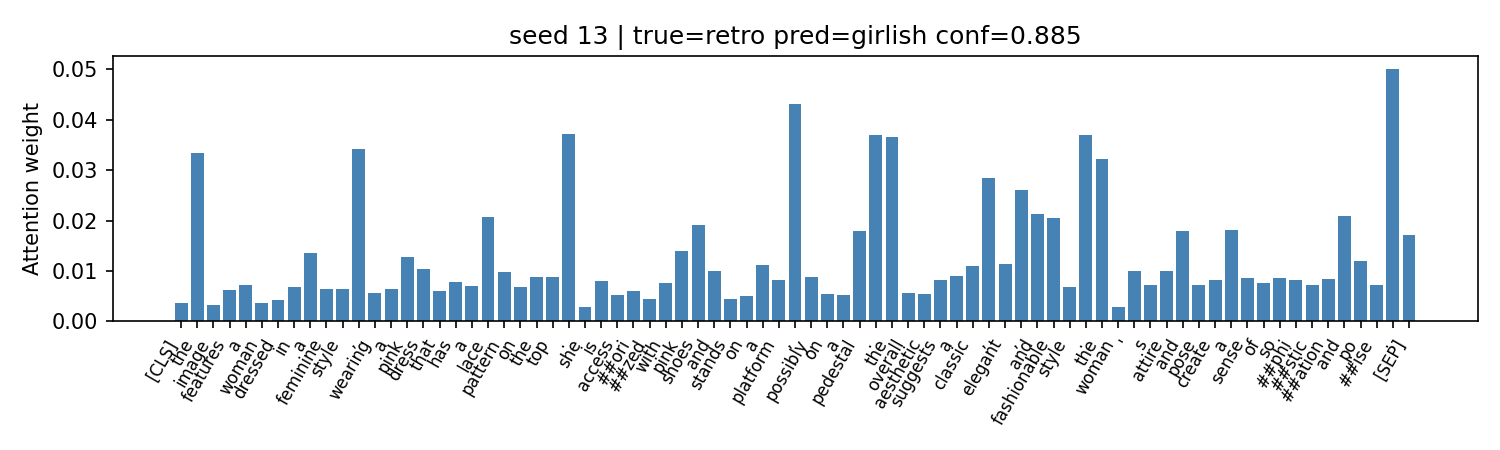

**Image-query attention heatmap**

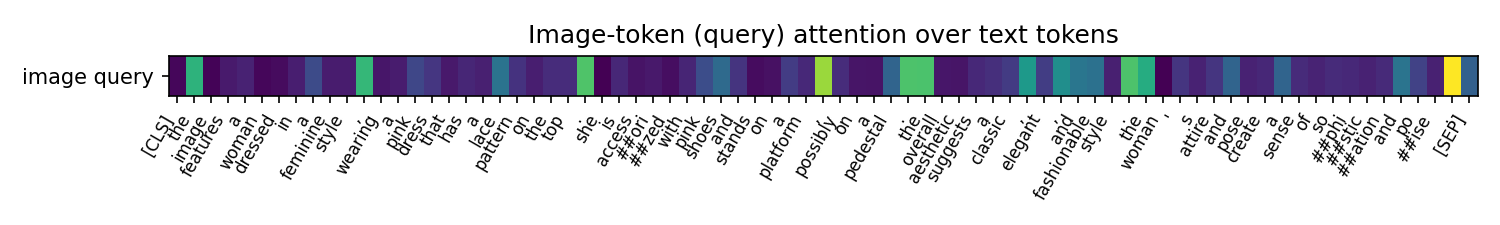

---

Saved case list: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\tables\04_cross_attention_case_studies.csv


In [5]:
# Cross-attention robustness summary (8_cross-attention.ipynb)
agg_path = PROPOSED_ROOT / "aggregation_summary.csv"
if agg_path.is_file():
    df_agg = pd.read_csv(agg_path)
    display(Markdown("### Proposed cross-attention — 10-seed test metrics (`8_cross-attention.ipynb`)"))
    display(df_agg.style.hide(axis="index"))
else:
    display(Markdown("_`aggregation_summary.csv` not found — run `8_cross-attention.ipynb` section 8._"))

attn_summary_path = EXPLAIN_ROOT / "attention_weights" / "all_seeds_sample_attention_summary.csv"
df_attn_samples = pd.read_csv(attn_summary_path)

df_seed_attn = df_attn_samples[df_attn_samples["seed"] == EXAMPLE_SEED].copy()
df_seed_attn["correct"] = df_seed_attn["true"] == df_seed_attn["pred"]

rng = np.random.default_rng(RANDOM_STATE)


def sample_attn_cases(correct: bool, n: int) -> pd.DataFrame:
    pool = df_seed_attn[df_seed_attn["correct"] == correct]
    if len(pool) <= n:
        return pool.copy()
    idx = rng.choice(len(pool), size=n, replace=False)
    return pool.iloc[idx].copy()


df_correct = sample_attn_cases(True, N_CROSS_ATTN_EACH)
df_incorrect = sample_attn_cases(False, N_CROSS_ATTN_EACH)
df_cases = pd.concat([df_correct, df_incorrect], ignore_index=True)
df_cases.to_csv(TABLE_OUT / "04_cross_attention_case_studies.csv", index=False, encoding="utf-8")

_, _, test_df = split_by_seed(df_mm, EXAMPLE_SEED)
attn_dir = EXPLAIN_ROOT / "attention_weights" / f"seed_{EXAMPLE_SEED}"


def show_cross_attention_case(row: pd.Series) -> None:
    idx = int(row["sample_idx"])
    sample = test_df.iloc[idx]
    status = "✅ Correct" if row["true"] == row["pred"] else "❌ Incorrect"

    display(
        Markdown(
            f"### {status} | sample `{idx:02d}` | seed {EXAMPLE_SEED}\n\n"
            f"- **True style:** `{row['true']}`\n"
            f"- **Predicted:** `{row['pred']}`\n"
            f"- **Confidence:** {row['confidence']:.3f}\n"
            f"- **Peak attended token:** `{row['max_attn_token']}`\n"
        )
    )

    img_path = Path(sample["abs_path"])
    if img_path.is_file():
        img = Image.open(img_path).convert("RGB")
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title("Input image", fontsize=10)
        fig.tight_layout()
        plt.show()
        plt.close(fig)
    else:
        display(Markdown(f"_Image not found: `{img_path}`_"))

    caption = str(sample["caption"])
    display(Markdown(f"**Caption:** {caption[:500]}{'…' if len(caption) > 500 else ''}"))

    bar_png = attn_dir / f"sample_{idx:02d}_text_token_attention.png"
    heat_png = attn_dir / f"sample_{idx:02d}_image_query_heatmap.png"

    if bar_png.is_file():
        display(Markdown("**Cross-attention over text tokens (bar)**"))
        display(IPyImage(filename=str(bar_png), width=700))
    else:
        display(Markdown(f"_Attention bar plot missing: `{bar_png}`_"))

    if heat_png.is_file():
        display(Markdown("**Image-query attention heatmap**"))
        display(IPyImage(filename=str(heat_png), width=700))
    else:
        display(Markdown(f"_Attention heatmap missing: `{heat_png}`_"))

    display(Markdown("---"))


display(Markdown(f"## Case studies for seed **{EXAMPLE_SEED}** (3 correct + 3 incorrect)"))

display(Markdown("### Correct predictions"))
for _, row in df_correct.iterrows():
    show_cross_attention_case(row)

display(Markdown("### Incorrect predictions"))
for _, row in df_incorrect.iterrows():
    show_cross_attention_case(row)

print("Saved case list:", TABLE_OUT / "04_cross_attention_case_studies.csv")

In [ ]:
from pathlib import Path
import pandas as pd, numpy as np

_root = Path.cwd()
_se = _root / "robustness" / "qwen_caption_evaluation" / "splits_eval"
if not _se.is_dir():
    _se = _root / "qwen_caption_evaluation" / "splits_eval"

agg = pd.read_csv(_se / "aggregation_mean_std_by_split.csv").set_index(["split", "metric"])

METRICS = {
    "CLIP Similarity (%)": ("clip_similarity_mean", 100, 2),
    "CLIP-IQA (%)":        ("clip_iqa_win_rate",    100, 2),
    "BLIP Score":          ("blip_itm_mean",           1, 4),
}
SPLITS = [("train", "Train"), ("val", "Validation"), ("test", "Test")]
PM = chr(0xb1)

rows_t1 = []
for label, (col, scale, dp) in METRICS.items():
    row = {"Metric": label}
    for sk, sd in SPLITS:
        m = agg.loc[(sk, col), "mean"] * scale
        s = agg.loc[(sk, col), "std"]  * scale
        row[f"{sd} (Mean {PM} Std)"] = f"{m:.{dp}f} {PM} {s:.{dp}f}"
    rows_t1.append(row)

table1 = pd.DataFrame(rows_t1)
print("Table 1: Overall Caption Quality")
print(table1)

STYLE_METRICS = {
    "CLIP Similarity (%)": ("clip_similarity", "clip_similarity", 100, 2),
    "CLIP-IQA (%)":        ("clip_iqa",        "clip_iqa_margin",    100, 2),
    "BLIP Score":          ("blipscore",        "blip_itm_score",    1, 4),
}

style_stats = {}
for label, (subdir, value_col, scale, dp) in STYLE_METRICS.items():
    per_seed = []
    for f in sorted((_se / subdir).glob("seed_*_test_per_sample.csv")):
        df = pd.read_csv(f)
        per_seed.append(df.groupby("style")[value_col].mean())
    seeds_df = pd.DataFrame(per_seed)
    style_stats[label] = (seeds_df.mean(), seeds_df.std(), scale, dp)

styles = sorted(style_stats["BLIP Score"][0].index)
rows_t2 = []
for st in styles:
    row = {"Style": st}
    for label, (mu, sigma, scale, dp) in style_stats.items():
        row[label] = f"{mu[st]*scale:.{dp}f} {PM} {sigma[st]*scale:.{dp}f}"
    rows_t2.append(row)

table2 = pd.DataFrame(rows_t2)
print("\nTable 2: Test Split Per-Style Caption Quality")
print(table2)

Table 1: Overall Caption Quality
                Metric Train (Mean ± Std) Validation (Mean ± Std)  \
0  CLIP Similarity (%)       31.68 ± 0.02            31.70 ± 0.06   
1         CLIP-IQA (%)       96.26 ± 0.20            96.24 ± 0.45   
2           BLIP Score    0.9590 ± 0.0005         0.9595 ± 0.0020   

  Test (Mean ± Std)  
0      31.66 ± 0.06  
1      96.24 ± 0.52  
2   0.9594 ± 0.0024  

Table 2: Test Split Per-Style Caption Quality
             Style CLIP Similarity (%)  CLIP-IQA (%)       BLIP Score
0     conservative        32.41 ± 0.19   7.82 ± 0.18  0.9726 ± 0.0084
1           dressy        31.37 ± 0.19  12.17 ± 0.34  0.9793 ± 0.0051
2           ethnic        32.21 ± 0.19   9.68 ± 0.21  0.9734 ± 0.0084
3            fairy        31.27 ± 0.19   9.95 ± 0.22  0.9222 ± 0.0150
4         feminine        31.50 ± 0.22   7.71 ± 0.24  0.9616 ± 0.0098
5              gal        30.88 ± 0.16   8.13 ± 0.20  0.9377 ± 0.0112
6          girlish        31.51 ± 0.20   7.90 ± 0.20  0.9713 ± 0.

In [ ]:
from pathlib import Path
import pandas as pd, numpy as np

_root = Path.cwd()
_se = _root / "robustness" / "qwen_caption_evaluation" / "splits_eval"
if not _se.is_dir():
    _se = _root / "qwen_caption_evaluation" / "splits_eval"

agg = pd.read_csv(_se / "aggregation_mean_std_by_split.csv").set_index(["split", "metric"])

METRICS = {
    "CLIP Similarity (%)": ("clip_similarity_mean", 100, 2),
    "CLIP-IQA (%)":        ("clip_iqa_win_rate",    100, 2),
    "BLIP Score":          ("blip_itm_mean",           1, 4),
}
SPLITS = [("train", "Train"), ("val", "Validation"), ("test", "Test")]
PM = chr(0xb1)

rows_t1 = []
for label, (col, scale, dp) in METRICS.items():
    row = {"Metric": label}
    for sk, sd in SPLITS:
        m = agg.loc[(sk, col), "mean"] * scale
        s = agg.loc[(sk, col), "std"]  * scale
        row[f"{sd} (Mean {PM} Std)"] = f"{m:.{dp}f} {PM} {s:.{dp}f}"
    rows_t1.append(row)

table1 = pd.DataFrame(rows_t1)
print("Table 1: Overall Caption Quality")
print(table1)

STYLE_METRICS = {
    "CLIP Similarity (%)": ("clip_similarity", "clip_similarity", 100, 2),
    "CLIP-IQA (%)":        ("clip_iqa",        "clip_iqa_margin",    100, 2),
    "BLIP Score":          ("blipscore",        "blip_itm_score",    1, 4),
}

style_stats = {}
for label, (subdir, value_col, scale, dp) in STYLE_METRICS.items():
    per_seed = []
    for f in sorted((_se / subdir).glob("seed_*_test_per_sample.csv")):
        df = pd.read_csv(f)
        per_seed.append(df.groupby("style")[value_col].mean())
    seeds_df = pd.DataFrame(per_seed)
    style_stats[label] = (seeds_df.mean(), seeds_df.std(), scale, dp)

styles = sorted(style_stats["BLIP Score"][0].index)
rows_t2 = []
for st in styles:
    row = {"Style": st}
    for label, (mu, sigma, scale, dp) in style_stats.items():
        row[label] = f"{mu[st]*scale:.{dp}f} {PM} {sigma[st]*scale:.{dp}f}"
    rows_t2.append(row)

table2 = pd.DataFrame(rows_t2)
print("\nTable 2: Test Split Per-Style Caption Quality")
print(table2)

Table 1: Overall Caption Quality
                Metric Train (Mean ± Std) Validation (Mean ± Std)  \
0  CLIP Similarity (%)       31.68 ± 0.02            31.70 ± 0.06   
1         CLIP-IQA (%)       96.26 ± 0.20            96.24 ± 0.45   
2           BLIP Score    0.9590 ± 0.0005         0.9595 ± 0.0020   

  Test (Mean ± Std)  
0      31.66 ± 0.06  
1      96.24 ± 0.52  
2   0.9594 ± 0.0024  

Table 2: Test Split Per-Style Caption Quality
             Style CLIP Similarity (%)  CLIP-IQA (%)       BLIP Score
0     conservative        32.41 ± 0.19   7.82 ± 0.18  0.9726 ± 0.0084
1           dressy        31.37 ± 0.19  12.17 ± 0.34  0.9793 ± 0.0051
2           ethnic        32.21 ± 0.19   9.68 ± 0.21  0.9734 ± 0.0084
3            fairy        31.27 ± 0.19   9.95 ± 0.22  0.9222 ± 0.0150
4         feminine        31.50 ± 0.22   7.71 ± 0.24  0.9616 ± 0.0098
5              gal        30.88 ± 0.16   8.13 ± 0.20  0.9377 ± 0.0112
6          girlish        31.51 ± 0.20   7.90 ± 0.20  0.9713 ± 0.